Loading the unhealthy dataset

In [1]:

# Import necessary libraries
import cv2
import os
from PIL import Image
import time
import matplotlib.pyplot as plt
import numpy as np



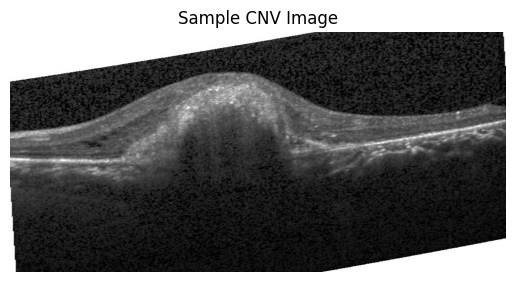

In [2]:

import cv2, os
from pathlib import Path

folder_path = Path("Data/CellData/OCT/test/CNV")
images_unhealthy = []

for file in folder_path.iterdir():
    if file.suffix.lower() in {".png", ".jpg", ".jpeg"}:
        img = cv2.imread(str(file), cv2.IMREAD_GRAYSCALE)  # returns a NumPy array
        if img is not None:
            images_unhealthy.append(img)

plt.imshow(images_unhealthy[3], cmap='gray')
plt.axis('off')
plt.title('Sample CNV Image')
plt.show()

Loading the healthy dataset

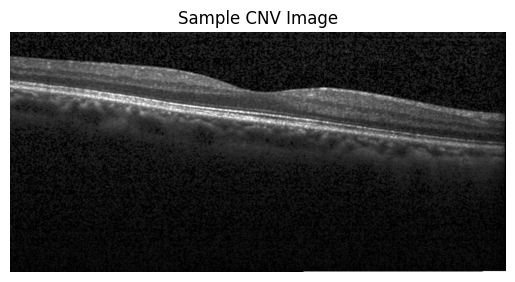

In [3]:

import cv2, os
from pathlib import Path

folder_path = Path("Data/CellData/OCT/test/Normal")
images_healthy = []

for file in folder_path.iterdir():
    if file.suffix.lower() in {".png", ".jpg", ".jpeg"}:
        img = cv2.imread(str(file), cv2.IMREAD_GRAYSCALE)  # returns a NumPy array
        if img is not None:
            images_healthy.append(img)

plt.imshow(images_healthy[3], cmap='gray')
plt.axis('off')
plt.title('Sample CNV Image')
plt.show()



Loading train Healthy

In [4]:
import cv2, os
from pathlib import Path

folder_path = Path("Data/CellData/OCT/train/Normal")
images_healthy_train = []

for file in folder_path.iterdir():
    if file.suffix.lower() in {".png", ".jpg", ".jpeg"}:
        img = cv2.imread(str(file), cv2.IMREAD_GRAYSCALE)  # returns a NumPy array
        if img is not None:
            images_healthy_train.append(img)


train unhealthy

In [5]:
import cv2, os
from pathlib import Path

folder_path = Path("Data/CellData/OCT/train/CNV")
images_unhealthy_train = []

for file in folder_path.iterdir():
    if file.suffix.lower() in {".png", ".jpg", ".jpeg"}:
        img = cv2.imread(str(file), cv2.IMREAD_GRAYSCALE)  # returns a NumPy array
        if img is not None:
            images_unhealthy_train.append(img)


Remove borders

Updated 250 unhealthy and 250 healthy images (white borders set to black).


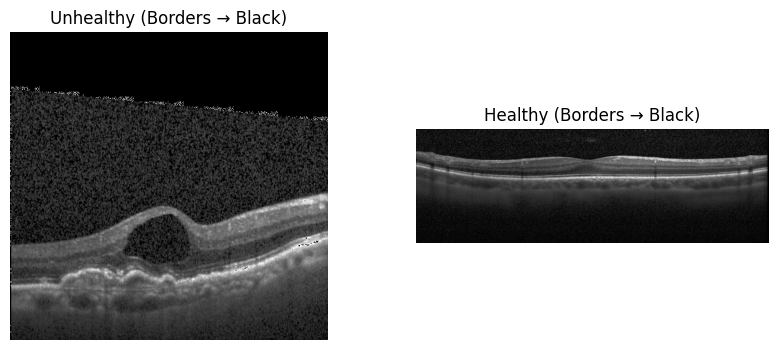

In [6]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Function to replace white border pixels with black
def remove_white_borders(arr, threshold=250):
    """
    Replace white pixels (>= threshold) with black (0).
    Works for 2D grayscale images.
    """
    arr = arr.copy()
    mask = arr >= threshold
    arr[mask] = 0
    return arr

# 🔄 Modify the existing arrays directly
for i in range(len(images_unhealthy)):
    images_unhealthy[i] = remove_white_borders(images_unhealthy[i])

for i in range(len(images_healthy)):
    images_healthy[i] = remove_white_borders(images_healthy[i])

for i in range(len(images_unhealthy_train)):
    images_unhealthy_train[i] = remove_white_borders(images_unhealthy_train[i])

for i in range(len(images_healthy_train)):
    images_healthy_train[i] = remove_white_borders(images_healthy_train[i])

print(f"Updated {len(images_unhealthy)} unhealthy and {len(images_healthy)} healthy images (white borders set to black).")

# Show before and after for one example
idx = 4
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(images_unhealthy_train[idx], cmap='gray')
plt.axis('off')
plt.title('Unhealthy (Borders → Black)')

plt.subplot(1, 2, 2)
plt.imshow(images_healthy_train[idx], cmap='gray')
plt.axis('off')
plt.title('Healthy (Borders → Black)')

plt.show()


Enhanced 250 unhealthy images and 250 healthy images.


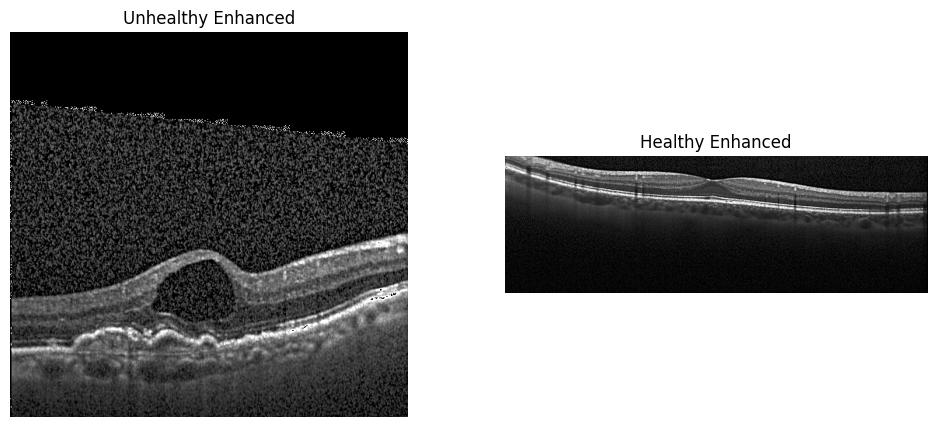

In [7]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def _ensure_odd_kernel(k):
    # Make sure Gaussian kernel size is valid (odd, >=1)
    if isinstance(k, int):
        return (k if k % 2 == 1 else k + 1)
    kh = k[0] if isinstance(k, tuple) else k
    kw = k[1] if isinstance(k, tuple) else k
    kh = kh if kh % 2 == 1 else kh + 1
    kw = kw if kw % 2 == 1 else kw + 1
    return (max(1, kh), max(1, kw))

def _to_gray_array(img):
    """Accepts np.ndarray (gray or RGB/BGR) or PIL.Image; returns 2D uint8 array."""
    if isinstance(img, np.ndarray):
        if img.ndim == 2:
            return img.astype(np.uint8, copy=False)
        elif img.ndim == 3:
            # Assume BGR (cv2) or RGB; if unsure, convert by averaging channels
            # Safer universal path: convert to gray with cv2 (assumes BGR)
            try:
                return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            except cv2.error:
                # Fallback: average channels
                return np.clip(img.mean(axis=2), 0, 255).astype(np.uint8)
    else:
        # PIL.Image
        return np.array(img.convert("L"), dtype=np.uint8)

def enhance_low_high_np(img, blur_kernel=(27, 27), highpass_weight=1.0, keep_type='ndarray'):
    """
    Apply Gaussian low-pass + high-pass enhancement.
    Accepts: np.ndarray or PIL.Image
    Returns: np.ndarray (grayscale) by default; set keep_type='pil' to get PIL.Image
    """
    k = _ensure_odd_kernel(blur_kernel)
    arr = _to_gray_array(img).astype(np.float32)

    # Low-pass (Gaussian blur)
    blurred = cv2.GaussianBlur(arr, k, 0)

    # High-pass
    highpass = arr - blurred

    # Combine
    sharpened = cv2.addWeighted(arr, 1.0, highpass, float(highpass_weight), 0)

    # Clip back to valid range
    sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

    if keep_type == 'pil':
        return Image.fromarray(sharpened)
    return sharpened

# 🧠 Apply to all images (lists may contain NumPy arrays now)
images_unhealthy_enhanced       = [enhance_low_high_np(img) for img in images_unhealthy]
images_healthy_enhanced         = [enhance_low_high_np(img) for img in images_healthy]
images_unhealthy_train_enhanced = [enhance_low_high_np(img) for img in images_unhealthy_train]
images_healthy_train_enhanced   = [enhance_low_high_np(img) for img in images_healthy_train]

print(f"Enhanced {len(images_unhealthy_enhanced)} unhealthy images and {len(images_healthy_enhanced)} healthy images.")

# 🔍 Show one example from each
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(images_unhealthy_train_enhanced[5], cmap='gray')
plt.axis('off')
plt.title('Unhealthy Enhanced')

plt.subplot(1, 2, 2)
plt.imshow(images_healthy_train_enhanced[5], cmap='gray')
plt.axis('off')
plt.title('Healthy Enhanced')

plt.show()


Filter

Only keep bright pixels

Line detection

Reverse colors to deteckt black pockets -> add them to the detect lines thingy

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import PIL.Image

def keep_inverted_top_band(pil_list, delta=20):
    """
    For each PIL 'L' image:
      - convert to grayscale ndarray
      - invert: new_pixel = 255 - old_pixel
      - find max intensity in inverted image
      - threshold at max - delta
      - keep original inverted values where >= threshold, else 0 (black)
    Returns list of uint8 numpy arrays.
    """
    out = []
    for im in pil_list:
        # ensure grayscale ndarray
        if isinstance(im, PIL.Image.Image):
            g = np.array(im.convert("L"), dtype=np.uint8)
        else:
            g = np.array(im, dtype=np.uint8)
        
        # invert the grayscale image
        inv = 255 - g
        
        # compute threshold
        maxv = int(inv.max())
        thr = max(0, maxv - int(delta))
        
        # keep only bright (white) pixels in inverted image
        keep = (inv >= thr)
        result = np.where(keep, inv, 0).astype(np.uint8)
        out.append(result)
    return out

# Apply to your variables
unhealthy_inv_top = keep_inverted_top_band(images_unhealthy_enhanced, delta=70)
healthy_inv_top   = keep_inverted_top_band(images_healthy_enhanced,   delta=70)
unhealthy_inv_top_train = keep_inverted_top_band(images_unhealthy_train_enhanced, delta=70)
healthy_inv_top_train   = keep_inverted_top_band(images_healthy_train_enhanced,   delta=70)

# Quick visual check
idx = 6
plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.imshow(unhealthy_inv_top[idx], cmap='gray'); plt.axis('off'); plt.title('Unhealthy (inverted) ≥ (max-70)')
plt.subplot(1,2,2); plt.imshow(healthy_inv_top[idx],   cmap='gray'); plt.axis('off');  plt.title('Healthy (inverted) ≥ (max-70)')
plt.show()


MemoryError: Unable to allocate 744. KiB for an array with shape (496, 1536) and data type uint8

noise removal

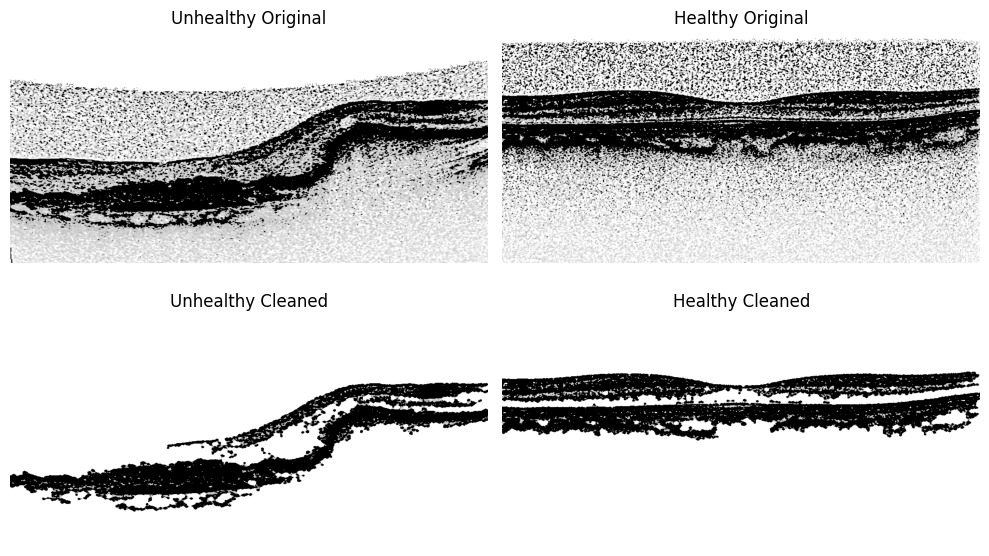

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def keep_main_object_preserve_intensity(img, thresh_val=110, morph_kernel=5):
    """
    Keep the largest dark connected component, preserve its intensities,
    and set everything else to 255.
    """
    # Threshold dark regions
    _, mask = cv2.threshold(img, thresh_val, 255, cv2.THRESH_BINARY_INV)

    # Morphological noise cleanup
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_kernel, morph_kernel))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=2)

    # Keep largest component only
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if num_labels > 1:
        largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        mask = np.where(labels == largest_label, 255, 0).astype(np.uint8)

    # Preserve interior, set outside to 255
    result = np.where(mask == 255, img, 255).astype(np.uint8)
    return result

# Choose idx
idx = 11
unhealthy_processed = keep_main_object_preserve_intensity(unhealthy_inv_top[idx])
healthy_processed = keep_main_object_preserve_intensity(healthy_inv_top[idx])
unhealthy_train_processed = keep_main_object_preserve_intensity(unhealthy_inv_top_train[idx])
healthy_train_processed = keep_main_object_preserve_intensity(healthy_inv_top_train[idx])

# Plot
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes[0,0].imshow(unhealthy_inv_top[idx], cmap='gray'); axes[0,0].set_title("Unhealthy Original"); axes[0,0].axis('off')
axes[0,1].imshow(healthy_inv_top[idx], cmap='gray'); axes[0,1].set_title("Healthy Original"); axes[0,1].axis('off')
axes[1,0].imshow(unhealthy_processed, cmap='gray'); axes[1,0].set_title("Unhealthy Cleaned"); axes[1,0].axis('off')
axes[1,1].imshow(healthy_processed, cmap='gray'); axes[1,1].set_title("Healthy Cleaned"); axes[1,1].axis('off')
plt.tight_layout()
plt.show()


Bubble detection

⚠️ Not enough samples per class for stratified split — using random split.
Train: (1, 496, 1024, 1)  Val: (1, 496, 1024, 1)  | Class counts: {np.int64(0): np.int64(1), np.int64(1): np.int64(1)}


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 496, 1024, 1)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 496, 1024, 1)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 496, 1024, 16)  │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 496, 1024, 16)  │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 496, 1024, 16)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 248, 512, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 248, 512, 32)   │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 248, 512, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 248, 512, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 124, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 124, 256, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 124, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 124, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 62, 128, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,697 (92.57 KB)

 Trainable params: 23,473 (91.69 KB)

 Non-trainable params: 224 (896.00 B)

Epoch 1/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.0000e+00 - auc: 0.0000e+00 - loss: 0.7112 - val_accuracy: 0.0000e+00 - val_auc: 0.0000e+00 - val_loss: 0.7117 - learning_rate: 0.0010
Epoch 2/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 0.6132 - val_accuracy: 0.0000e+00 - val_auc: 0.0000e+00 - val_loss: 0.7181 - learning_rate: 0.0010
Epoch 3/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 0.2338 - val_accuracy: 0.0000e+00 - val_auc: 0.0000e+00 - val_loss: 0.7253 - learning_rate: 0.0010
Epoch 4/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 0.2272
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 0.2272 - val_accuracy: 0.0000e+00 - val_auc: 0.0000e+00 - val_loss: 0.7327 - learning_rate: 0.0010
Epoch 5/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accur

C:\Users\mholz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mholz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mholz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classificati

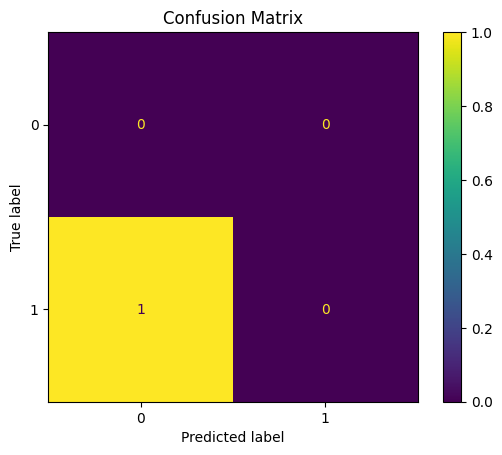

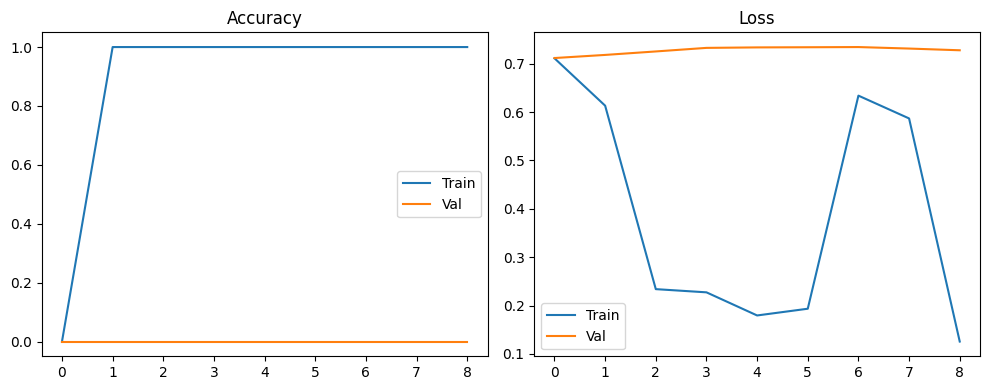

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


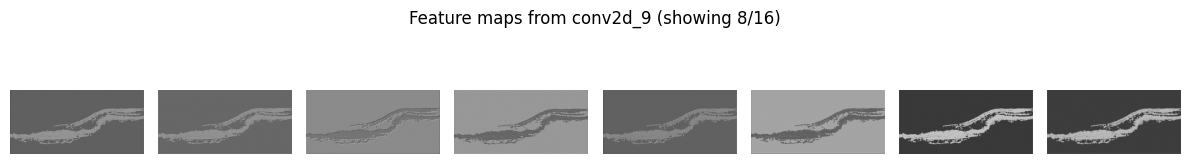

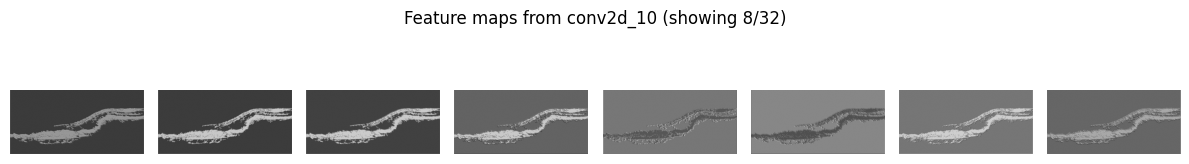

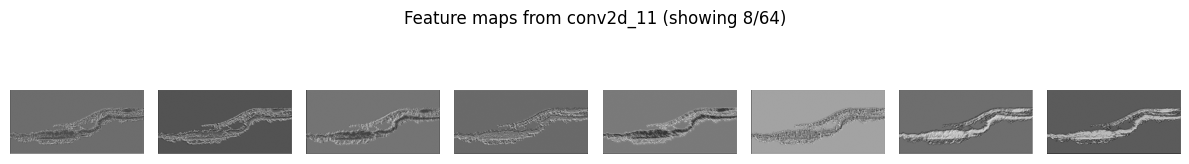

In [ ]:
# 🧠 CNN Training with 42k train images and 500 test images
# ---------------------------------------------------------
# Train on *_processed_train, evaluate on *_processed

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- Helper: convert list → NumPy array, normalize, add channel ---
def to_np(x):
    if isinstance(x, list):
        x = np.stack(x, axis=0)
    else:
        x = np.asarray(x)
    if x.ndim == 2:
        x = x[None, ...]
    if x.ndim == 4 and x.shape[-1] == 1:
        x = x[..., 0]  # remove redundant channel
    assert x.ndim == 3, f"Expected (N,H,W), got {x.shape}"
    return x

def make_xy(healthy, unhealthy):
    H = to_np(healthy)
    U = to_np(unhealthy)
    assert H.shape[1:] == U.shape[1:], f"Image size mismatch: {H.shape[1:]} vs {U.shape[1:]}"
    X = np.concatenate([H, U], axis=0).astype("float32") / 255.0
    y = np.concatenate([np.zeros(len(H)), np.ones(len(U))], axis=0).astype("int32")
    X = X[..., None]  # (N, H, W, 1)
    return X, y

# --- Prepare datasets ---
X_train, y_train = make_xy(healthy_processed_train, unhealthy_processed_train)
X_test,  y_test  = make_xy(healthy_processed,       unhealthy_processed)

print(f"Train: {X_train.shape}, positives={y_train.sum()}")
print(f"Test:  {X_test.shape},  positives={y_test.sum()}")

H, W, C = X_train.shape[1:]

# --- Data augmentation ---
aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomZoom(0.1),
], name="augmentation")

AUTOTUNE = tf.data.AUTOTUNE
batch_size = 64

# Dataset pipelines (efficient loading)
ds_train = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
    .shuffle(min(len(X_train), 20000)) \
    .map(lambda x, y: (aug(x, training=True), y), num_parallel_calls=AUTOTUNE) \
    .batch(batch_size).prefetch(AUTOTUNE)

ds_val = tf.data.Dataset.from_tensor_slices((X_train[:4000], y_train[:4000])) \
    .batch(batch_size).prefetch(AUTOTUNE)  # small validation set

ds_test = tf.data.Dataset.from_tensor_slices((X_test, y_test)) \
    .batch(batch_size).prefetch(AUTOTUNE)

# --- Build CNN ---
def build_cnn(input_shape):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(16, 3, padding="same", use_bias=False)(inputs)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(32, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(64, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(128, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])
    return model

model = build_cnn((H, W, C))
model.summary()

# --- Train ---
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1),
]

history = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=25,
    callbacks=callbacks,
    verbose=1
)

# --- Evaluate on test set ---
test_probs = model.predict(ds_test).ravel()
test_preds = (test_probs >= 0.5).astype(int)

print("\n📊 Test set report:\n", classification_report(y_test, test_preds, digits=3))
ConfusionMatrixDisplay.from_predictions(y_test, test_preds)
plt.title("Confusion Matrix - Test Set")
plt.show()

# --- Training curves ---
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.title("Accuracy"); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.title("Loss"); plt.legend()
plt.tight_layout(); plt.show()
